In [7]:
import pandas as pd

df = pd.read_json(
    "../data/states_2022-06-27-23.json",
)
df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1656370800,ab58b2,31.046356,-82.843700,234.974796,354.975925,0.00000,DAL595,False,False,False,6132.0,10058.40,10660.38,1.656371e+09,1.656371e+09
1,1656370800,406814,43.580246,-71.207055,276.689582,34.546929,0.32512,VIR4C,False,False,False,3056.0,11277.60,11734.80,1.656371e+09,1.656371e+09
2,1656370800,ab2729,40.973831,-74.659180,231.792277,98.166070,-0.97536,AAL1092,False,False,False,7126.0,6111.24,6370.32,1.656371e+09,1.656371e+09
3,1656370800,a4fdb1,30.097977,-81.700433,200.026121,339.840638,0.00000,TMB197,False,False,False,1363.0,11277.60,11925.30,1.656371e+09,1.656371e+09
4,1656370800,c066b0,29.776749,-81.097694,253.161860,183.845054,0.00000,SWG626,False,False,False,6340.0,10972.80,11612.88,1.656371e+09,1.656371e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2475776,1656374390,48418b,42.413977,21.748139,256.996575,153.999168,0.00000,KLM44Q,False,False,False,2663.0,11887.20,12390.12,1.656374e+09,1.656374e+09
2475777,1656374390,a19c2e,40.845657,-74.418274,57.620025,179.488444,-2.27584,N20226,False,False,False,1200.0,365.76,373.38,1.656374e+09,1.656374e+09
2475778,1656374390,ab5a01,35.747543,-112.078972,225.901844,240.983416,0.00000,SCX407,False,False,False,3641.0,11574.78,12237.72,1.656374e+09,1.656374e+09
2475779,1656374390,a981c9,43.733414,-81.022190,188.289315,269.686911,4.55168,N711WS,False,False,False,6306.0,6667.50,6797.04,1.656374e+09,1.656374e+09


In [16]:
df.isna().sum()

time                  0
icao24                0
lat              157438
lon              157438
velocity         222439
heading          222439
vertrate         221613
callsign          65861
onground              0
alert                 0
spi                   0
baroaltitude     227249
lastposupdate    157438
lastcontact           0
dtype: int64

In [13]:
df.isna().sum() / len(df)

time             0.000000
icao24           0.000000
lat              0.063591
lon              0.063591
velocity         0.089846
heading          0.089846
vertrate         0.089512
callsign         0.026602
onground         0.000000
alert            0.000000
spi              0.000000
squawk           0.494893
baroaltitude     0.091789
geoaltitude      0.118836
lastposupdate    0.063591
lastcontact      0.000000
dtype: float64

In [23]:
if "squawk" in df.columns:
    df.drop(columns=["squawk", "geoaltitude"], inplace=True)

categorical_cols = df.select_dtypes(include="str").columns
numerical_cols = df.select_dtypes(exclude="str").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].value_counts().index[0])

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

df.isna().any().any()

np.False_

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df[numerical_cols])

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

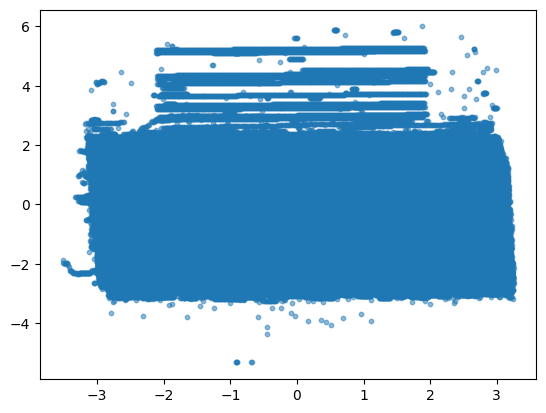

In [29]:
import matplotlib.pyplot as plt

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5, s=10)
plt.show()